In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [6]:
%%time
#загружаем базу данных взаимодействия РНК с белками с http://www.rnainter.org/
rnainter = pd.read_csv('/home/v_mandybura/mandybura_data/minobr24/rna_interactions/databases/rna_simchrom_inter.csv', sep=';', header=0, low_memory=False)

CPU times: user 25 s, sys: 3.23 s, total: 28.2 s
Wall time: 28.3 s


In [3]:
rnainter.head()

,Unnamed: 0,Interactor2.Symbol,Protein,Protein names,UniProt Localization,HPA Localization,OpenCell Localization,SimChrom Category,SimChrom-SL Category,MS-based studies,...,Category1,Species1,Category2,Species2,Raw_ID1,Raw_ID2,score,strong,weak,predict
0,204616,BIRC5,O15392,Baculoviral IAP repeat-containing protein 5,"Centromere (ECO:0000269), Chromosome (ECO:0000...",Cytokinetic bridge (Supported),NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,miRNA,Homo sapiens,protein,Homo sapiens,miRBase:MIMAT0027626,NCBI:332,0.4183,NaN,HITS-CLIP//PAR-CLIP,NaN
1,467793,DCTN3,O75935,Dynactin subunit 3 (p22),"Centrosome (ECO:0000269), Cleavage furrow (ECO...",Cytosol (Approved),NaN,Centromere-associated,Centromere-associated,NaN,...,miRNA,Homo sapiens,protein,Homo sapiens,miRBase:MIMAT0000750,NCBI:11258,0.2114,NaN,HITS-CLIP,NaN
2,467794,DCTN3,O75935,Dynactin subunit 3 (p22),"Centrosome (ECO:0000269), Cleavage furrow (ECO...",Cytosol (Approved),NaN,Centromere-associated,Centromere-associated,NaN,...,miRNA,Homo sapiens,protein,Homo sapiens,miRBase:MIMAT0018349,NCBI:11258,0.2114,NaN,HITS-CLIP,NaN
3,467795,DCTN3,O75935,Dynactin subunit 3 (p22),"Centrosome (ECO:0000269), Cleavage furrow (ECO...",Cytosol (Approved),NaN,Centromere-associated,Centromere-associated,NaN,...,miRNA,Homo sapiens,protein,Homo sapiens,miRBase:MIMAT0019758,NCBI:11258,0.2114,NaN,HITS-CLIP,NaN
4,467796,DCTN3,O75935,Dynactin subunit 3 (p22),"Centrosome (ECO:0000269), Cleavage furrow (ECO...",Cytosol (Approved),NaN,Centromere-associated,Centromere-associated,NaN,...,miRNA,Homo sapiens,protein,Homo sapiens,miRBase:MIMAT0019769,NCBI:11258,0.2114,NaN,HITS-CLIP,NaN


In [2]:
rnainter_db = pd.read_csv('/home/v_mandybura/mandybura_data/minobr24/rna_interactions/databases/rnainter_db_2606205.txt', sep='\t', header=0, low_memory=False)

In [3]:
lnc_rnainter_db = rnainter_db[rnainter_db['Category1'] == 'lncRNA'] 

In [7]:
lnc_rnainter = rnainter[rnainter['Category1'] == 'lncRNA'] 

In [4]:
lnc_rnainter_db

,RNAInterID,Interactor1.Symbol,Category1,Species1,Interactor2.Symbol,Category2,Species2,Raw_ID1,Raw_ID2,score,strong,weak,predict
0,RP34107012,0610005C13Rik,lncRNA,Mus musculus,A1cf,RBP,Mus musculus,NCBI:71661,NCBI:69865,0.1229,NaN,NaN,Scan pipeline widely used MATCH algorithm
1,RP26906421,0610005C13Rik,lncRNA,Mus musculus,Abcc8,protein,Mus musculus,NCBI:71661,NCBI:20927,0.1841,NaN,NaN,catRAPID
2,RP28542059,0610005C13Rik,lncRNA,Mus musculus,Abcc9,protein,Mus musculus,NCBI:71661,NCBI:20928,0.1841,NaN,NaN,catRAPID
3,RP03379796,0610005C13Rik,lncRNA,Mus musculus,Ahr,TF,Mus musculus,NCBI:71661,NCBI:11622,0.2495,NaN,ChIP-seq,NaN
4,RP03173502,0610005C13Rik,lncRNA,Mus musculus,Ar,TF,Mus musculus,NCBI:71661,NCBI:11835,0.3083,NaN,ChIP-seq,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37067242,RP34479121,CDKN1A,lncRNA,Homo sapiens,RBM24,RBP,Homo sapiens,NCBI:1026,NCBI:221662,0.3909,qRT-PCR//TaqMan qPCR//Western blot//Luciferase...,TaqMan miRNA array,Scan pipeline widely used MATCH algorithm
37067247,RP09609376,MEG3,lncRNA,Homo sapiens,ILF3,RBP,Homo sapiens,NCBI:55384,NCBI:3609,0.4547,RT-PCR//IP//Western blot//RNA pull-down assay/...,eCLIP,NaN
37067248,RP09426531,MEG3,lncRNA,Homo sapiens,SMO,protein,Homo sapiens,NCBI:55384,NCBI:6608,0.3591,qRT-PCR//Western blot//Luciferase reporter ass...,NaN,TargetScan
37067257,RP00099192,ZFAS1,lncRNA,Homo sapiens,SP1,TF,Homo sapiens,NCBI:441951,NCBI:6667,0.4721,ChIP//Western blot//ISH//Biotin pull-down assa...,ChIP-seq,PicTar//miRanda


In [104]:
lnc_rnainter

,Unnamed: 0,Interactor2.Symbol,Protein,Protein names,UniProt Localization,HPA Localization,OpenCell Localization,SimChrom Category,SimChrom-SL Category,MS-based studies,...,Category1,Species1,Category2,Species2,Raw_ID1,Raw_ID2,score,strong,weak,predict
482,2546135,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,Ensembl:ENSG00000260060,NCBI:5905,0.2331,NaN,eCLIP,NaN
484,2546133,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,Ensembl:ENSG00000233937,NCBI:5905,0.3051,NaN,eCLIP,catRAPID
485,2546132,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,Ensembl:ENSG00000267009,NCBI:5905,0.2331,NaN,eCLIP,NaN
486,2546131,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,Ensembl:ENSG00000227946,NCBI:5905,0.3051,NaN,eCLIP,catRAPID
487,2546130,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,Ensembl:ENSG00000229970,NCBI:5905,0.3051,NaN,eCLIP,catRAPID
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3697751,3525995,YTHDC1,Q96MU7,YTH domain-containing protein 1 (YT521-B),"Nucleus (ECO:0000269), Nucleus speckle (ECO:00...","Nucleoplasm (Approved), Plasma membrane (Appro...",NaN,X-chromosome inactivation,X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,protein,Homo sapiens,NCBI:285962,NCBI:91746,0.2042,CLIP,NaN,NaN
3697756,3525999,YTHDC1,Q96MU7,YTH domain-containing protein 1 (YT521-B),"Nucleus (ECO:0000269), Nucleus speckle (ECO:00...","Nucleoplasm (Approved), Plasma membrane (Appro...",NaN,X-chromosome inactivation,X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,protein,Homo sapiens,NCBI:100874113,NCBI:91746,0.2042,CLIP,NaN,NaN
3697758,3526001,YTHDC1,Q96MU7,YTH domain-containing protein 1 (YT521-B),"Nucleus (ECO:0000269), Nucleus speckle (ECO:00...","Nucleoplasm (Approved), Plasma membrane (Appro...",NaN,X-chromosome inactivation,X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,NCBI:441951,NCBI:91746,0.3479,CLIP,iCLIP//PAR-CLIP,catRAPID
3697761,3526004,YTHDC1,Q96MU7,YTH domain-containing protein 1 (YT521-B),"Nucleus (ECO:0000269), Nucleus speckle (ECO:00...","Nucleoplasm (Approved), Plasma membrane (Appro...",NaN,X-chromosome inactivation,X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,lncRNA,Homo sapiens,RBP,Homo sapiens,NCBI:148898,NCBI:91746,0.2571,NaN,PAR-CLIP,NaN


In [5]:
lnc_rnainter_db = lnc_rnainter_db[lnc_rnainter_db['Species1'] == 'Homo sapiens']

In [70]:
lnc_rnainter_db

,RNAInterID,Interactor1.Symbol,Category1,Species1,Interactor2.Symbol,Category2,Species2,Raw_ID1,Raw_ID2,score,strong,weak,predict
431677,RP33978966,7SL,lncRNA,Homo sapiens,APOBEC3F,protein,Homo sapiens,NaN,NCBI:200316,0.2869,qRT-PCR//Western blot//IP,NaN,NaN
431678,RP33978964,7SL,lncRNA,Homo sapiens,APOBEC3G,protein,Homo sapiens,NaN,NCBI:60489,0.3686,qRT-PCR//Western blot//IP,NaN,NaN
431679,RP33978965,7SL,lncRNA,Homo sapiens,APOBEC3H,protein,Homo sapiens,NaN,NCBI:164668,0.3686,qRT-PCR//Western blot//IP,NaN,NaN
439948,RP09425804,91H,lncRNA,Homo sapiens,CTCF,TF,Homo sapiens,NaN,NCBI:10664,0.3184,ChIP//qRT-PCR,NaN,NaN
439949,RP09425803,91H,lncRNA,Homo sapiens,MYC,TF,Homo sapiens,NaN,NCBI:4609,0.3184,ChIP//qRT-PCR,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37067242,RP34479121,CDKN1A,lncRNA,Homo sapiens,RBM24,RBP,Homo sapiens,NCBI:1026,NCBI:221662,0.3909,qRT-PCR//TaqMan qPCR//Western blot//Luciferase...,TaqMan miRNA array,Scan pipeline widely used MATCH algorithm
37067247,RP09609376,MEG3,lncRNA,Homo sapiens,ILF3,RBP,Homo sapiens,NCBI:55384,NCBI:3609,0.4547,RT-PCR//IP//Western blot//RNA pull-down assay/...,eCLIP,NaN
37067248,RP09426531,MEG3,lncRNA,Homo sapiens,SMO,protein,Homo sapiens,NCBI:55384,NCBI:6608,0.3591,qRT-PCR//Western blot//Luciferase reporter ass...,NaN,TargetScan
37067257,RP00099192,ZFAS1,lncRNA,Homo sapiens,SP1,TF,Homo sapiens,NCBI:441951,NCBI:6667,0.4721,ChIP//Western blot//ISH//Biotin pull-down assa...,ChIP-seq,PicTar//miRanda


In [71]:
lnc_rnainter_db['Interactor1.Symbol'].nunique()

29130

In [72]:
lnc_rnainter['Interactor1.Symbol'].nunique()

23396

In [73]:
del rnainter_db 
del lnc_rnainter_db

In [6]:
simchrom = pd.read_csv('/home/v_mandybura/mandybura_data/minobr24/rna_interactions/databases/simchrom_chromprots_30092025.csv', sep=',', header=0, low_memory=False)

In [4]:
simchrom["Protein"].nunique()

3045

In [7]:
simchrom

,Gene,Protein,Protein names,UniProt Localization,HPA Localization,OpenCell Localization,SimChrom Category,SimChrom-SL Category,MS-based studies,"Abundance, ppm",PFAM,Protein length,Protein complexes
0,AARS1,P49588,"Alanine--tRNA ligase, cytoplasmic","Cytoplasm (ECO:0000255), Cytoplasm (ECO:0000269)",Cytosol (Supported),NaN,"Nuclear RNA binding proteins, RNA modification",RNA modification,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",186.000,"tRNA-synt_2c(tRNA synthetases class II (A),PF0...",968,NaN
1,AATF,Q9NY61,Protein AATF,Nucleolus (ECO:0000269),"Nucleoli (Supported), Nucleoplasm (Approved)",nucleolus_gc (annotations_grade_3),"Nuclear RNA binding proteins, Preribosome-asso...",Preribosome-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",24.600,TRAUB(Apoptosis-antagonizing transcription fac...,560,"Small ribosomal subunit processome,CPX-2511,EC..."
2,ABHD2,P08910,Monoacylglycerol lipase ABHD2,"Cell membrane (ECO:0000305), Flagellum membran...","Cytosol (Approved), Nucleoplasm (Approved)",NaN,"DNA-templated transcription, Regulation of tra...",Nuclear hormone receptors,NaN,0.127,"Abhydrolase_1(alpha/beta hydrolase fold,PF00561)",425,NaN
3,ABL1,P00519,Tyrosine-protein kinase ABL1,Mitochondrion (ECO:0000250),"Nuclear bodies (Enhanced), Nucleoplasm (Enhanced)",NaN,"DNA metabolic processes, DNA repair",DNA repair,NaN,5.010,"SH2(SH2 domain,PF00017);SH3_1(SH3 domain,PF000...",1130,NaN
4,ABRAXAS1,Q6UWZ7,BRCA1-A complex subunit Abraxas 1,Nucleus (ECO:0000269),Nuclear bodies (Supported),NaN,"DNA metabolic processes, DNA repair",DNA repair,"Alabert et al., 2014; Itzhak et al., 2016; Kus...",2.740,MPN_2A_DUB_like(PF21125),409,"BRCA1-A complex,CPX-4425,ECO:0005547(biologica..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3040,ZW10,O43264,Centromere/kinetochore protein zw10 homolog,"Cytoplasm (ECO:0000269), Endoplasmic reticulum...","Cytosol (Supported), Endoplasmic reticulum (Su...",NaN,Centromere-associated,Centromere-associated,"Alvarez et al., 2023; Shi et al., 2021",21.900,"Zw10_N(Centromere/kinetochore Zw10,PF06248);ZW...",779,"RZZ complex,CPX-6017,ECO:0000353(physical inte..."
3041,ZWILCH,Q9H900,Protein zwilch homolog (hZwilch),Kinetochore (ECO:0000269),NaN,NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Shi et al., 2021",5.580,"Zwilch(RZZ complex, subunit zwilch,PF09817)",591,"RZZ complex,CPX-6017,ECO:0000353(physical inte..."
3042,ZWINT,O95229,ZW10 interactor (Zwint-1),NaN,"Cytosol (Supported), Nuclear bodies (Enhanced)...",NaN,Centromere-associated,Centromere-associated,"Shi et al., 2021",4.380,"Zwint(ZW10 interactor,PF15556)",277,"Kinetochore KNL1 complex,CPX-5644,ECO:0005547(..."
3043,ZZEF1,O43149,Zinc finger ZZ-type and EF-hand domain-contain...,NaN,"Mitochondria (Approved), Nucleoplasm (Approved)",NaN,Histone PTM readers,Histone PTM readers,NaN,5.000,"ZZ(Zinc finger, ZZ type,PF00569);ZZ(Zinc finge...",2961,NaN


In [8]:
lnc_rnainter["Interactor2.Symbol"].nunique()

725

In [9]:
simchrom_prots = simchrom["SimChrom-SL Category"].value_counts() #Количество белков в каждой категории SimChrom

In [10]:
simchrom_prots

SimChrom-SL Category
Non-Housekeeping DNA-binding TFs      755
Housekeeping DNA-binding TFs          511
DNA-acting enzymes                    192
RNA processing                        192
Centromere-associated                 145
DNA repair                             96
Histone PTM writers                    95
Chromatin remodelers                   91
Histone PTM readers                    81
Histone modification                   78
DNA replication                        71
Telomere-associated                    71
Preribosome-associated                 67
Regulation of transcription            61
Histones                               60
Nuclear hormone receptors              58
General TFs                            58
Histone PTM erasers                    51
RNA polymerases                        34
DNA recombination                      33
Histone chaperones                     32
Methylated DNA binding                 29
SMC complexes                          28
Other familie

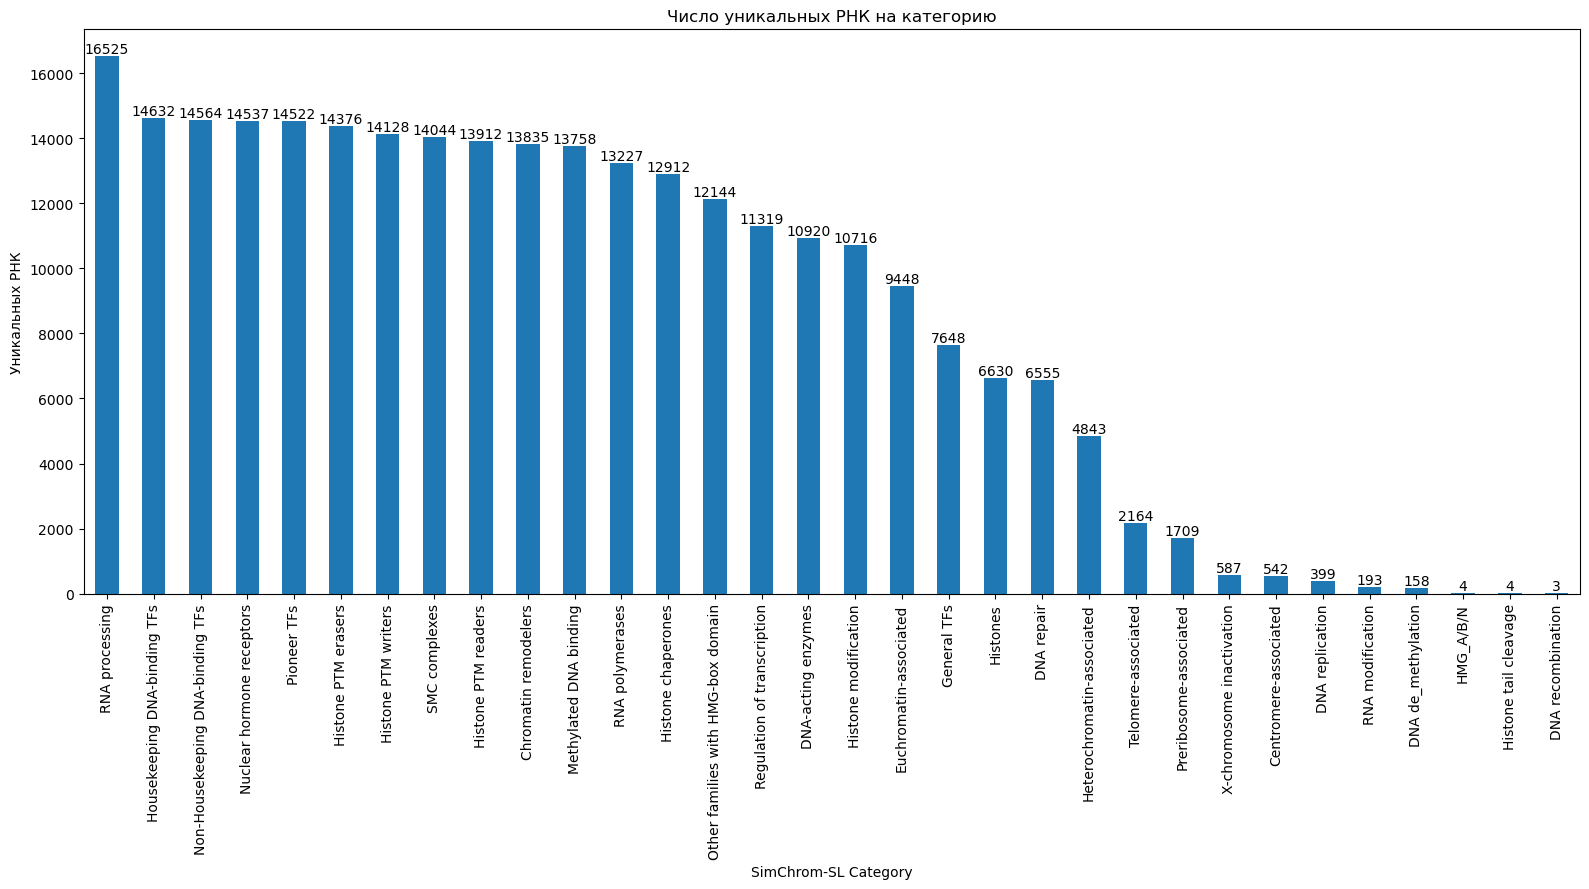

SimChrom-SL Category
RNA processing                        16525
Housekeeping DNA-binding TFs          14632
Non-Housekeeping DNA-binding TFs      14564
Nuclear hormone receptors             14537
Pioneer TFs                           14522
Histone PTM erasers                   14376
Histone PTM writers                   14128
SMC complexes                         14044
Histone PTM readers                   13912
Chromatin remodelers                  13835
Methylated DNA binding                13758
RNA polymerases                       13227
Histone chaperones                    12912
Other families with HMG-box domain    12144
Regulation of transcription           11319
DNA-acting enzymes                    10920
Histone modification                  10716
Euchromatin-associated                 9448
General TFs                            7648
Histones                               6630
DNA repair                             6555
Heterochromatin-associated             4843
Telomere-as

In [116]:
def rna_per_protein_group(df, 
                          rna_col="Interactor1.Symbol",   # колонка с РНК
                          prot_col="Interactor2.Symbol",  # колонка с белками
                          cat_col="SimChrom-SL Category", # колонка с группами белков
                          prot_counts=simchrom_prots,               # Series с количеством белков в категориях (если есть отдельно)
                          sort_desc=True,
                          figsize=(16, 9),
                          annotate=True):
    """
    df: датафрейм с взаимодействиями (РНК - белок - категория белка).
    prot_counts: Series (index=категория, value=количество белков в категории). 
                 Если None — считается как уникальные белки из df.
    """

    tmp = df[[rna_col, cat_col]].dropna().copy()
    tmp[cat_col] = tmp[cat_col].astype(str).str.strip()
    tmp[rna_col] = tmp[rna_col].astype(str).str.strip()

    # 2) число уникальных РНК на категорию (ключевой момент задачи)
    s = tmp.groupby(cat_col)[rna_col].nunique()

    # 3) сортировка
    if sort_desc:
        s = s.sort_values(ascending=False)

    # 4) график

        ax = s.plot(kind="bar", figsize=figsize)
        ax.set_ylabel("Уникальных РНК")
        ax.set_xlabel(cat_col)
        ax.set_title("Число уникальных РНК на категорию")
        if annotate:
            for i, v in enumerate(s.values):
                ax.text(i, v, f"{v}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
    return s
rna_per_protein_group(lnc_rnainter)

In [83]:
simchrom_prots.info()

<class 'pandas.core.series.Series'>
Index: 32 entries, Non-Housekeeping DNA-binding TFs to X-chromosome inactivation
Series name: count
Non-Null Count  Dtype
--------------  -----
32 non-null     int64
dtypes: int64(1)
memory usage: 1.5+ KB


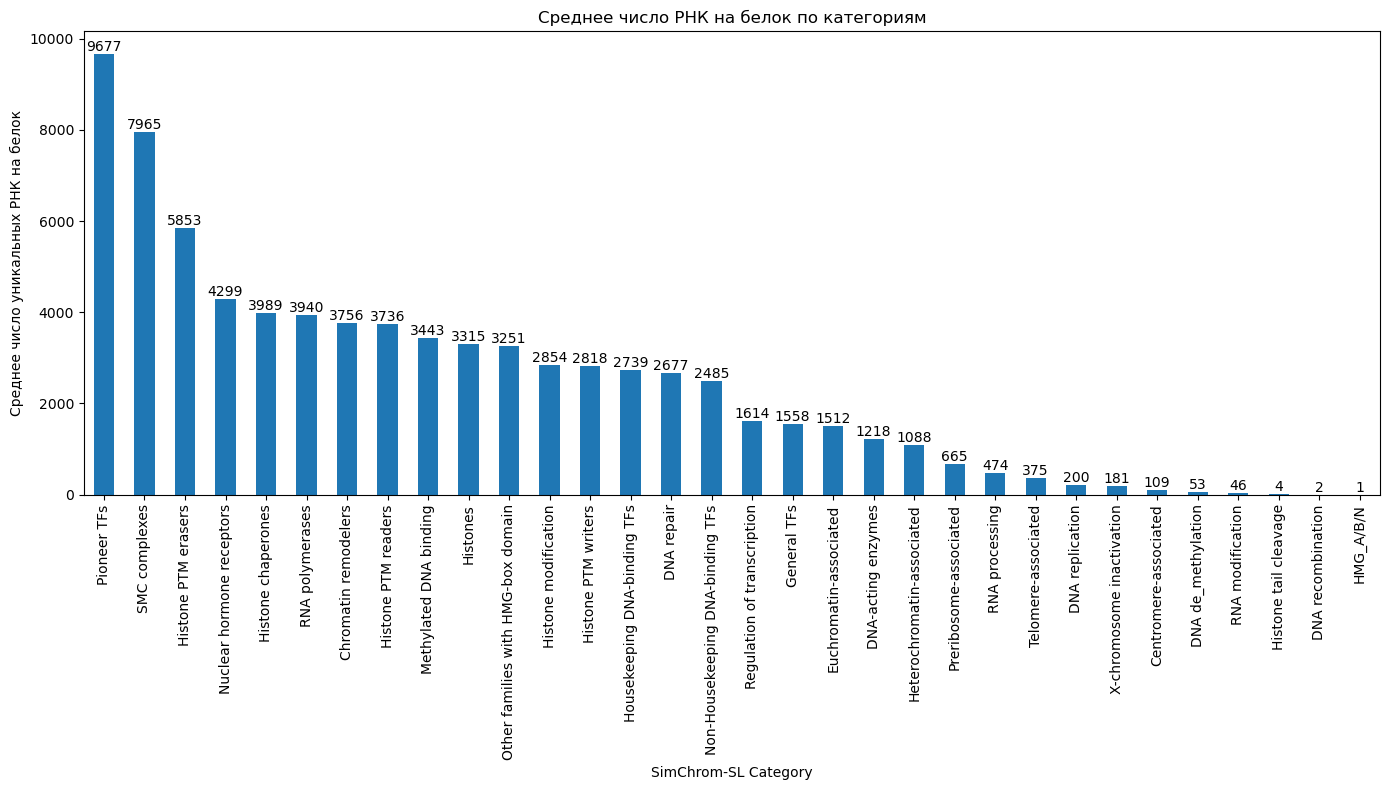

,sum_unique_rna,n_proteins_total,avg_unique_rna_per_protein
SimChrom-SL Category,,,
Pioneer TFs,154836,16.0,9677.250000
SMC complexes,47790,6.0,7965.000000
Histone PTM erasers,52677,9.0,5853.000000
Nuclear hormone receptors,146168,34.0,4299.058824
Histone chaperones,27920,7.0,3988.571429
RNA polymerases,15761,4.0,3940.250000
Chromatin remodelers,56347,15.0,3756.466667
Histone PTM readers,56038,15.0,3735.866667
Methylated DNA binding,34429,10.0,3442.900000


In [16]:
def avg_rnas_per_protein_in_group_simple(
    df,
    rna_col="Interactor1.Symbol",
    prot_col="Interactor2.Symbol",
    cat_col="SimChrom-SL Category",
    prot_counts=None,          # pd.Series(index=категория, values=число белков); опционально
    plot=True,
    figsize=(14,8),
    annotate=True,             # подписи на столбиках
    decimals=0,  # округление подписей
    horizontal=False
):
    # базовые колонки
    tmp = df[[rna_col, prot_col, cat_col]].dropna().copy()
    for c in (rna_col, prot_col, cat_col):
        tmp[c] = tmp[c].astype(str).str.strip()

    # 1) уникальные РНК на белок
    rnas_per_prot = (
        tmp.groupby(prot_col)[rna_col]
           .nunique()
           .rename("n_unique_rna")
    )

    # 2) категория каждого белка (однозначная)
    prot_cat = (
        tmp.drop_duplicates([prot_col, cat_col])
           .set_index(prot_col)[cat_col]
    )
    # на случай редких дублей оставим первую встречу
    prot_cat = prot_cat[~prot_cat.index.duplicated(keep="first")]

    # выравниваем множества белков
    common = rnas_per_prot.index.intersection(prot_cat.index)
    rnas_per_prot = rnas_per_prot.loc[common]
    prot_cat = prot_cat.loc[common]

    # 3) агрегация по категории: сумма и число белков, далее среднее
    sum_rna_by_cat = rnas_per_prot.groupby(prot_cat).sum().rename("sum_unique_rna")
    n_prot_by_cat_observed = pd.Series(prot_cat).value_counts().rename("n_proteins_observed")

    if prot_counts is not None:
        # знаменатель берём из переданного счётчика
        n_prot_by_cat = prot_counts.astype(float).rename("n_proteins_total")
    else:
        n_prot_by_cat = n_prot_by_cat_observed.astype(float).rename("n_proteins_total")

    # общий список категорий
    all_cats = sorted(set(sum_rna_by_cat.index) | set(n_prot_by_cat.index))
    sum_rna_by_cat = sum_rna_by_cat.reindex(all_cats, fill_value=0.0)
    n_prot_by_cat = n_prot_by_cat.reindex(all_cats, fill_value=0.0)

    # 4) среднее число РНК на белок
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_per_prot = (sum_rna_by_cat / n_prot_by_cat).replace([np.inf], np.nan)

    result = pd.DataFrame({
        "sum_unique_rna": sum_rna_by_cat,
        "n_proteins_total": n_prot_by_cat,
        "avg_unique_rna_per_protein": avg_per_prot
    }).sort_values("avg_unique_rna_per_protein", ascending=False, na_position="last")

    if plot:
        s = result["avg_unique_rna_per_protein"]
        if horizontal:
            ax = s.plot(kind="barh", figsize=figsize)
            ax.set_xlabel("Среднее число уникальных РНК на белок")
            ax.set_ylabel(cat_col)
            ax.set_title("Среднее число РНК на белок по категориям")

            if annotate:
                for i, (cat, val) in enumerate(s.items()):
                    if pd.notna(val):
                        ax.text(val, i, f" {val:.{decimals}f}", va="center")
        else:
            ax = s.plot(kind="bar", figsize=figsize)
            ax.set_ylabel("Среднее число уникальных РНК на белок")
            ax.set_xlabel(cat_col)
            ax.set_title("Среднее число РНК на белок по категориям")

            if annotate:
                for i, (cat, val) in enumerate(s.items()):
                    if pd.notna(val):
                        ax.text(i, val, f"{val:.{decimals}f}", ha="center", va="bottom")

        # небольшой отступ сверху/справа, чтобы подписи не упирались в рамку
        if not s.dropna().empty:
            pad = max(s.dropna().max() * 0.05, 0.1)
            if horizontal:
                ax.set_xlim(left=0, right=s.dropna().max() + pad)
            else:
                ax.set_ylim(bottom=0, top=s.dropna().max() + pad)

        plt.tight_layout()
        plt.show()
    return result
avg_rnas_per_protein_in_group_simple(lnc_rnainter)

In [17]:
lnc1 = pd.read_csv('lncrna1.csv', sep=',') #Дифференциальная экспрессия lnc в ковиде из doi: 10.1111/jcmm.16444

In [18]:
lnc1.head()

,Unnamed: 0,ensemblID,logFC,AveExpr,t,P.Value,adj.P.Val,B,symbol
0,2,ENSG00000122043,-1.695520,-0.516159,-4.218802,1.508880e-04,6.970543e-04,0.292535,LINC00544
1,8,ENSG00000131484,-1.763750,-0.588587,-5.030175,1.264615e-05,7.482748e-05,2.712103,AC091132.1
2,15,ENSG00000153363,-1.631083,-0.134238,-5.371828,4.366673e-06,2.838575e-05,3.757308,LINC00467
3,17,ENSG00000163597,-1.765747,3.883320,-7.225301,1.367907e-08,1.738606e-07,9.465854,SNHG16
4,21,ENSG00000170161,-1.666074,-1.017796,-7.051329,2.333167e-08,2.761540e-07,8.935418,AL512625.1


In [65]:
lnc_rnainter['SimChrom-SL Category'].value_counts()

SimChrom-SL Category
Non-Housekeeping DNA-binding TFs      506865
Housekeeping DNA-binding TFs          457406
Pioneer TFs                           154836
Nuclear hormone receptors             146168
Histone PTM writers                    70441
Chromatin remodelers                   62501
Histone PTM readers                    56038
Histone PTM erasers                    52677
SMC complexes                          47790
RNA processing                         46433
Methylated DNA binding                 34429
Other families with HMG-box domain     32509
Histone chaperones                     27920
Histone modification                   25688
Regulation of transcription            22591
DNA-acting enzymes                     21927
RNA polymerases                        15761
General TFs                            14020
Euchromatin-associated                 12093
DNA repair                              8031
Histones                                6630
Heterochromatin-associated        

In [92]:
cols = ["Interactor2.Symbol", "SimChrom-SL Category"]
lnc_rnainter_prots = lnc_rnainter[cols].dropna(subset=["Interactor2.Symbol"]).drop_duplicates(subset=["Interactor2.Symbol"]).copy()
lnc_rnainter_prots # уникальные взаимодействующие (с точки зрения rnainter) с lncRNA белки хроматина с их SimChrom-SL категориями

,Interactor2.Symbol,SimChrom-SL Category
482,RANGAP1,Centromere-associated
1023,AHCTF1,Centromere-associated
1987,CCNB1,Centromere-associated
2188,PRPF4B,Centromere-associated
2434,PLK3,Centromere-associated
...,...,...
3694188,ALYREF,Telomere-associated
3695871,METTL3,X-chromosome inactivation
3695925,YTHDC1,X-chromosome inactivation
3696767,RBM15,X-chromosome inactivation


                                    numerator_in_df_unique_first  \
category                                                           
Pioneer TFs                                                   16   
Nuclear hormone receptors                                     34   
X-chromosome inactivation                                      4   
RNA processing                                                98   
Other families with HMG-box domain                            10   
Euchromatin-associated                                         8   
RNA modification                                               8   
Methylated DNA binding                                        10   
Housekeeping DNA-binding TFs                                 167   
HMG_A/B/N                                                      3   
Non-Housekeeping DNA-binding TFs                             204   
Histone PTM writers                                           25   
Regulation of transcription                     

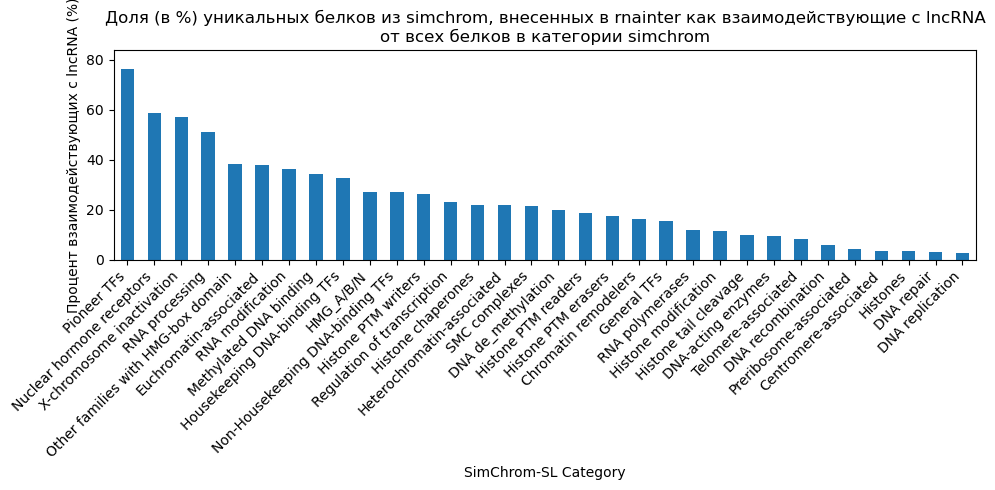

,numerator_in_df_unique_first,total_in_simchrom_prots,percent
category,,,
Pioneer TFs,16,21.0,76.190476
Nuclear hormone receptors,34,58.0,58.620690
X-chromosome inactivation,4,7.0,57.142857
RNA processing,98,192.0,51.041667
Other families with HMG-box domain,10,26.0,38.461538
Euchromatin-associated,8,21.0,38.095238
RNA modification,8,22.0,36.363636
Methylated DNA binding,10,29.0,34.482759
Housekeeping DNA-binding TFs,167,511.0,32.681018


In [87]:
def plot_fraction_in_unique(
    protein_counts_by_category: pd.Series,
    unique_interaction_proteins: pd.DataFrame,
    cat_col: str = "SimChrom-SL Category",
    sort_by: str = "percent",   # "percent" или "numerator" или None
    figsize=(10, 5),
    fillna_percent_with_zero: bool = False
):
    # 1) числитель: сколько вхождений каждой категории в df_unique_first
    numer = unique_interaction_proteins[cat_col].astype(str).str.strip().value_counts()
    # 2) знаменатель: simchrom_prots (предполагаем, что это Series с индексом = категории)
    denom = protein_counts_by_category.copy()

    # 3) общий индекс (включая категории, которые есть только в одном из наборов)
    all_cats = sorted(set(denom.index.astype(str)).union(set(numer.index.astype(str))))

    numer = numer.reindex(all_cats).fillna(0).astype(int)
    denom = denom.reindex(all_cats).fillna(0).astype(float)

    # 4) процент: (числитель / знаменатель) * 100
    # избегаем деления на 0: результат NaN там, где denom == 0
    with np.errstate(divide='ignore', invalid='ignore'):
        percent = (numer / denom) * 100
    percent[denom == 0] = np.nan

    # опционально заменить NaN на 0
    if fillna_percent_with_zero:
        percent = percent.fillna(0.0)

    # 5) собрать таблицу
    result = pd.DataFrame({
        "category": all_cats,
        "numerator_in_df_unique_first": numer.values,
        "total_in_simchrom_prots": denom.values,
        "percent": percent.values
    }).set_index("category")

    # 6) сортировка для вывода
    if sort_by == "percent":
        result = result.sort_values("percent", ascending=False, na_position="last")
    elif sort_by == "numerator":
        result = result.sort_values("numerator_in_df_unique_first", ascending=False)

    # 7) печать таблицы (пара столбцов, округление процентов)
    display_df = result.copy()
    display_df["percent"] = display_df["percent"].round(2)
    print(display_df)

    # 8) барплот
    ax = display_df["percent"].plot(kind="bar", figsize=figsize)
    ax.set_ylabel("Процент взаимодействующих с lncRNA (%)")
    ax.set_xlabel("SimChrom-SL Category")
    ax.set_title("Доля (в %) уникальных белков из simchrom, внесенных в rnainter как взаимодействующие с lncRNA\nот всех белков в категории simchrom")
    ax.set_ylim(0, max( (display_df["percent"].dropna().max() * 1.1), 5 ))  # немного сверху для красоты
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return result

# Пример использования:
# result_df = plot_fraction_in_unique(simchrom_prots, df_unique_first)
plot_fraction_in_unique(simchrom_prots, lnc_rnainter_prots)

In [19]:
lnc1.rename(columns={'symbol' : 'Interactor1.Symbol'}, inplace=True) 

In [20]:
lnc1

,Unnamed: 0,ensemblID,logFC,AveExpr,t,P.Value,adj.P.Val,B,Interactor1.Symbol
0,2,ENSG00000122043,-1.695520,-0.516159,-4.218802,1.508880e-04,6.970543e-04,0.292535,LINC00544
1,8,ENSG00000131484,-1.763750,-0.588587,-5.030175,1.264615e-05,7.482748e-05,2.712103,AC091132.1
2,15,ENSG00000153363,-1.631083,-0.134238,-5.371828,4.366673e-06,2.838575e-05,3.757308,LINC00467
3,17,ENSG00000163597,-1.765747,3.883320,-7.225301,1.367907e-08,1.738606e-07,9.465854,SNHG16
4,21,ENSG00000170161,-1.666074,-1.017796,-7.051329,2.333167e-08,2.761540e-07,8.935418,AL512625.1
...,...,...,...,...,...,...,...,...,...
682,4068,ENSG00000284719,-1.590284,0.002229,-6.367388,1.942855e-07,1.796394e-06,6.832549,AL033527.4
683,4071,ENSG00000284735,1.691469,-1.082093,4.726293,3.231683e-05,1.747518e-04,1.793148,AL139424.3
684,4087,ENSG00000285106,-1.538632,3.091860,-4.593007,4.861505e-05,2.531232e-04,1.394334,AC016831.6
685,4095,ENSG00000285280,-2.032510,0.282318,-6.026879,5.627835e-07,4.613555e-06,5.779567,AL390957.1


In [21]:
covid_lnc1 = pd.merge(lnc_rnainter, lnc1, on='Interactor1.Symbol', how='inner')

In [12]:
covid_lnc1 # взаимодействия согласно rnainter lnc из doi: 10.1111/jcmm.16444 с белками из SimChrom 

,Unnamed: 0_x,Interactor2.Symbol,Protein,Protein names,UniProt Localization,HPA Localization,OpenCell Localization,SimChrom Category,SimChrom-SL Category,MS-based studies,...,weak,predict,Unnamed: 0_y,ensemblID,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,2546121,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP,NaN,3002,ENSG00000268205,-2.203357,2.397329,-9.085471,5.497153e-11,1.344565e-09,14.952829
1,2546159,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP,NaN,2712,ENSG00000263126,-2.205414,-0.945993,-11.466047,8.808457e-14,7.562689e-12,21.344303
2,2546233,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP,NaN,576,ENSG00000228106,-2.571755,0.442023,-10.208543,2.407950e-12,1.023257e-10,18.062436
3,2546270,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP,NaN,261,ENSG00000223745,-2.410607,3.781823,-10.192888,2.512437e-12,1.046517e-10,18.020243
4,2546193,RANGAP1,P46060,Ran GTPase-activating protein 1 (RanGAP1),"Cytoplasm (ECO:0000269), Cytoplasm (ECO:000030...","Cytosol (Supported), Nuclear membrane (Support...",NaN,Centromere-associated,Centromere-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP,NaN,2731,ENSG00000263603,-2.046223,-1.679260,-6.015642,5.829164e-07,4.752576e-06,5.744800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86471,2571694,RBM15,Q96T37,RNA-binding protein 15,"Nucleoplasm (ECO:0000269), Nucleus envelope (E...",Nucleoplasm (Enhanced),"chromatin (annotations_grade_3), nucleoplasm (...","Nuclear RNA binding proteins, RNA modification...",X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP//iCLIP,NaN,285,ENSG00000224032,-2.551108,0.623872,-8.551113,2.575658e-10,5.081462e-09,13.416356
86472,2571695,RBM15,Q96T37,RNA-binding protein 15,"Nucleoplasm (ECO:0000269), Nucleus envelope (E...",Nucleoplasm (Enhanced),"chromatin (annotations_grade_3), nucleoplasm (...","Nuclear RNA binding proteins, RNA modification...",X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP//iCLIP,NaN,2496,ENSG00000260565,-2.179375,3.378189,-7.654647,3.704543e-09,5.337332e-08,10.764356
86473,2571706,RBM15,Q96T37,RNA-binding protein 15,"Nucleoplasm (ECO:0000269), Nucleus envelope (E...",Nucleoplasm (Enhanced),"chromatin (annotations_grade_3), nucleoplasm (...","Nuclear RNA binding proteins, RNA modification...",X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP//iCLIP,NaN,1276,ENSG00000237424,-1.871496,0.364264,-7.733674,2.918433e-09,4.323187e-08,11.001538
86474,2571711,RBM15,Q96T37,RNA-binding protein 15,"Nucleoplasm (ECO:0000269), Nucleus envelope (E...",Nucleoplasm (Enhanced),"chromatin (annotations_grade_3), nucleoplasm (...","Nuclear RNA binding proteins, RNA modification...",X-chromosome inactivation,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,eCLIP//iCLIP,NaN,1098,ENSG00000234741,-2.560419,3.872374,-7.938654,1.576791e-09,2.581152e-08,11.613852


<Axes: >

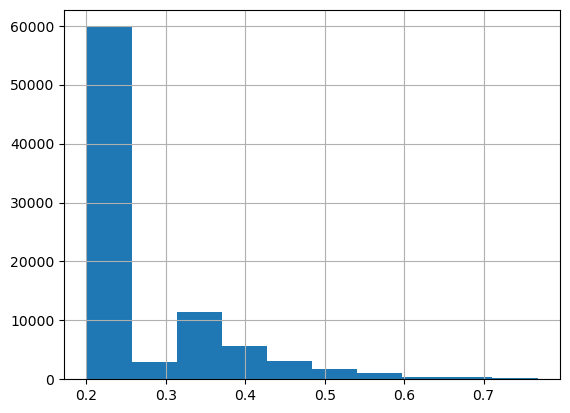

In [22]:
covid_lnc1['score'].hist()

In [88]:
covid_lnc1_prots = covid_lnc1[cols].dropna(subset=["Interactor2.Symbol"]).drop_duplicates(subset=["Interactor2.Symbol"]).copy()

In [89]:
covid_lnc1_prots

,Interactor2.Symbol,SimChrom-SL Category
0,RANGAP1,Centromere-associated
6,AHCTF1,Centromere-associated
47,DEK,Chromatin remodelers
361,ERCC6,Chromatin remodelers
596,RB1,Chromatin remodelers
...,...,...
86331,HNRNPA2B1,Telomere-associated
86342,ALYREF,Telomere-associated
86385,METTL3,X-chromosome inactivation
86393,YTHDC1,X-chromosome inactivation


In [93]:
lnc_rnainter_prots = lnc_rnainter_prots['SimChrom-SL Category'].value_counts()
lnc_rnainter_prots

SimChrom-SL Category
Non-Housekeeping DNA-binding TFs      204
Housekeeping DNA-binding TFs          167
RNA processing                         98
Nuclear hormone receptors              34
Histone PTM writers                    25
DNA-acting enzymes                     18
Pioneer TFs                            16
Histone PTM readers                    15
Chromatin remodelers                   15
Regulation of transcription            14
Other families with HMG-box domain     10
Methylated DNA binding                 10
Histone PTM erasers                     9
General TFs                             9
Histone modification                    9
Euchromatin-associated                  8
RNA modification                        8
Histone chaperones                      7
Telomere-associated                     6
SMC complexes                           6
Centromere-associated                   5
Heterochromatin-associated              5
X-chromosome inactivation               4
RNA polymeras

                                    numerator_in_df_unique_first  \
category                                                           
Euchromatin-associated                                         8   
Histone PTM erasers                                            9   
SMC complexes                                                  6   
Pioneer TFs                                                   16   
Preribosome-associated                                         3   
RNA polymerases                                                4   
Housekeeping DNA-binding TFs                                 163   
Histone PTM readers                                           14   
Non-Housekeeping DNA-binding TFs                             190   
RNA processing                                                90   
Methylated DNA binding                                         9   
Other families with HMG-box domain                             9   
Nuclear hormone receptors                       

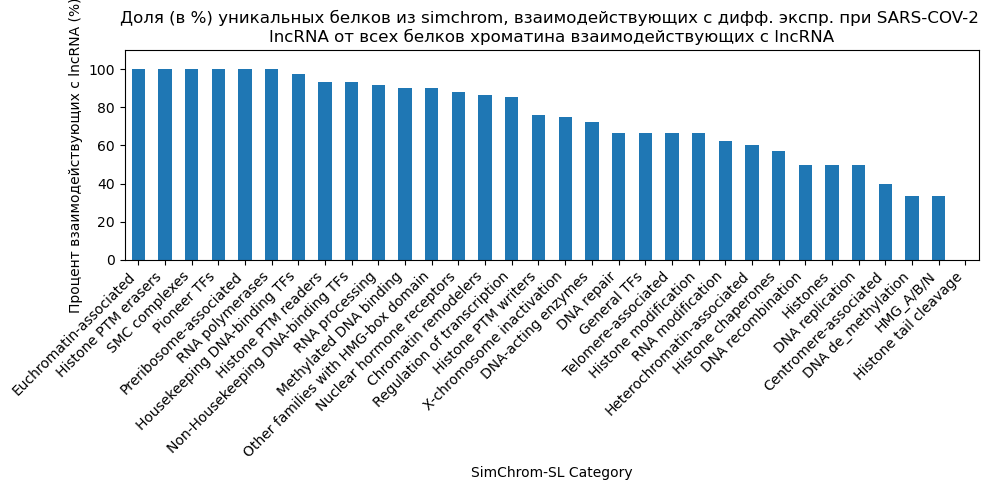

,numerator_in_df_unique_first,total_in_simchrom_prots,percent
category,,,
Euchromatin-associated,8,8.0,100.000000
Histone PTM erasers,9,9.0,100.000000
SMC complexes,6,6.0,100.000000
Pioneer TFs,16,16.0,100.000000
Preribosome-associated,3,3.0,100.000000
RNA polymerases,4,4.0,100.000000
Housekeeping DNA-binding TFs,163,167.0,97.604790
Histone PTM readers,14,15.0,93.333333
Non-Housekeeping DNA-binding TFs,190,204.0,93.137255


In [95]:

def plot_fraction(
    protein_counts_by_category: pd.DataFrame,
    unique_interaction_proteins: pd.DataFrame,
    cat_col: str = "SimChrom-SL Category",
    sort_by: str = "percent",   # "percent" или "numerator" или None
    figsize=(10, 5),
    fillna_percent_with_zero: bool = False
):
    # 1) числитель: сколько вхождений каждой категории в df_unique_first
    numer = unique_interaction_proteins[cat_col].astype(str).str.strip().value_counts()
    # 2) знаменатель: simchrom_prots (предполагаем, что это Series с индексом = категории)
    denom = protein_counts_by_category.copy()

    # 3) общий индекс (включая категории, которые есть только в одном из наборов)
    all_cats = sorted(set(denom.index.astype(str)).union(set(numer.index.astype(str))))

    numer = numer.reindex(all_cats).fillna(0).astype(int)
    denom = denom.reindex(all_cats).fillna(0).astype(float)

    # 4) процент: (числитель / знаменатель) * 100
    # избегаем деления на 0: результат NaN там, где denom == 0
    with np.errstate(divide='ignore', invalid='ignore'):
        percent = (numer / denom) * 100
    percent[denom == 0] = np.nan

    # опционально заменить NaN на 0
    if fillna_percent_with_zero:
        percent = percent.fillna(0.0)

    # 5) собрать таблицу
    result = pd.DataFrame({
        "category": all_cats,
        "numerator_in_df_unique_first": numer.values,
        "total_in_simchrom_prots": denom.values,
        "percent": percent.values
    }).set_index("category")

    # 6) сортировка для вывода
    if sort_by == "percent":
        result = result.sort_values("percent", ascending=False, na_position="last")
    elif sort_by == "numerator":
        result = result.sort_values("numerator_in_df_unique_first", ascending=False)

    # 7) печать таблицы (пара столбцов, округление процентов)
    display_df = result.copy()
    display_df["percent"] = display_df["percent"].round(2)
    print(display_df)

    # 8) барплот
    ax = display_df["percent"].plot(kind="bar", figsize=figsize)
    ax.set_ylabel("Процент взаимодействующих с lncRNA (%)")
    ax.set_xlabel("SimChrom-SL Category")
    ax.set_title("Доля (в %) уникальных белков из simchrom, взаимодействующих с дифф. экспр. при SARS-COV-2 \nlncRNA от всех белков хроматина взаимодействующих с lncRNA")
    ax.set_ylim(0, max( (display_df["percent"].dropna().max() * 1.1), 5 ))  # немного сверху для красоты
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return result
plot_fraction(lnc_rnainter_prots, covid_lnc1_prots)

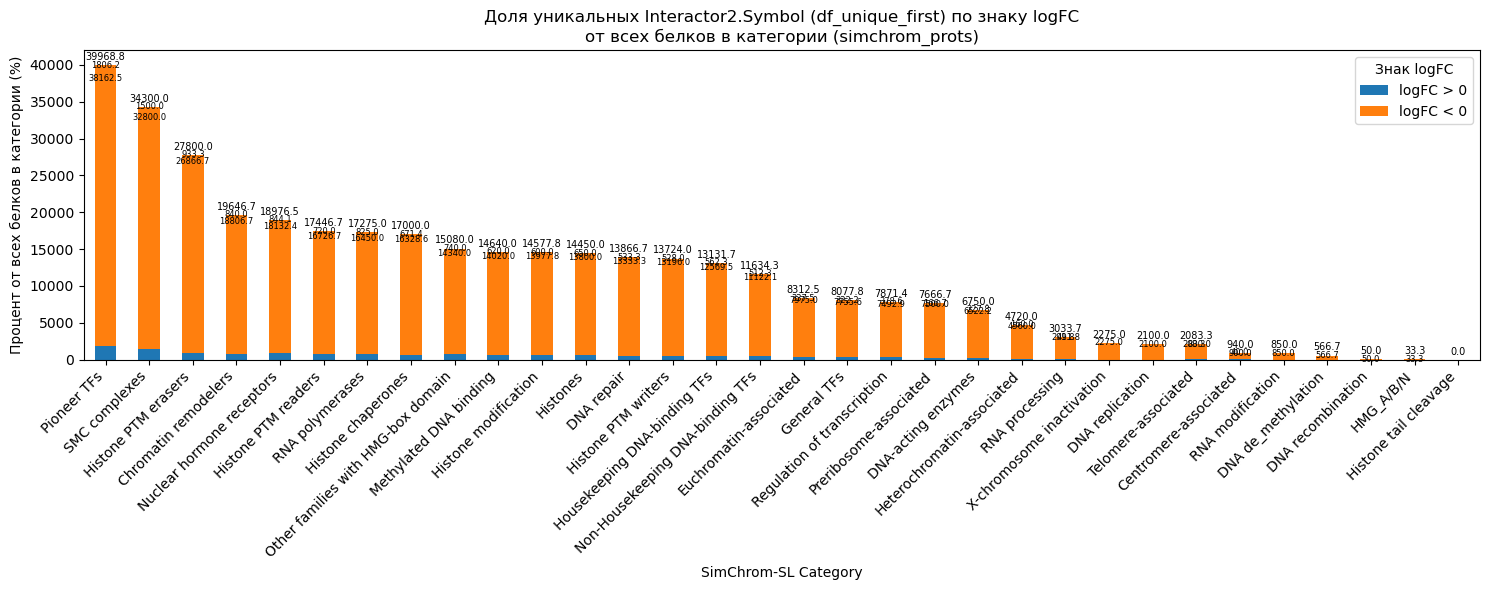

,numer_pos,numer_neg,denom,percent_pos,percent_neg,total_percent
Pioneer TFs,289,6106,16.0,1806.250000,38162.500000,39968.750000
SMC complexes,90,1968,6.0,1500.000000,32800.000000,34300.000000
Histone PTM erasers,84,2418,9.0,933.333333,26866.666667,27800.000000
Chromatin remodelers,126,2821,15.0,840.000000,18806.666667,19646.666667
Nuclear hormone receptors,287,6165,34.0,844.117647,18132.352941,18976.470588
Histone PTM readers,108,2509,15.0,720.000000,16726.666667,17446.666667
RNA polymerases,33,658,4.0,825.000000,16450.000000,17275.000000
Histone chaperones,47,1143,7.0,671.428571,16328.571429,17000.000000
Other families with HMG-box domain,74,1434,10.0,740.000000,14340.000000,15080.000000
Methylated DNA binding,62,1402,10.0,620.000000,14020.000000,14640.000000


In [103]:
def plot_pos_neg_fraction_by_category(
    simchrom_prots: pd.Series,
    df_unique_first: pd.DataFrame,
    cat_col: str = "SimChrom-SL Category",
    val_col: str = "logFC",
    figsize=(15, 6),
    annotate=True,
    fillna_percent_with_zero: bool = False,
    sort_by: str = "total_percent"   # "total_percent", "percent_pos", "percent_neg", or None
):
    # проверки
    if cat_col not in df_unique_first.columns:
        raise ValueError(f"В df_unique_first нет колонки '{cat_col}'.")
    if val_col not in df_unique_first.columns:
        raise ValueError(f"В df_unique_first нет колонки '{val_col}' (нужна для знака logFC).")

    # подготовка: приведение к строкам/числам и удаление NaN в ключевых полях
    df = df_unique_first[[cat_col, val_col]].copy()
    df[cat_col] = df[cat_col].astype(str).str.strip()
    df = df.dropna(subset=[cat_col, val_col])

    # поскольку df_unique_first предполагается уникальной по Interactor2.Symbol,
    # достаточно просто посчитать количество строк в каждой категории с pos/neg
    pos_counts = (df[df[val_col] > 0]
                  .groupby(cat_col)
                  .size()
                  .rename("numer_pos"))
    neg_counts = (df[df[val_col] < 0]
                  .groupby(cat_col)
                  .size()
                  .rename("numer_neg"))
    total_counts_in_unique = (pos_counts.reindex(simchrom_prots.index, fill_value=0)
                              .add(neg_counts.reindex(simchrom_prots.index, fill_value=0), fill_value=0)
                              .rename("numer_total"))

    # знаменатель — simchrom_prots (возможно Series с индексом = категории)
    denom = simchrom_prots.copy().astype(float).rename("denom")
    # общий набор категорий
    all_cats = sorted(set(denom.index.astype(str)).union(set(pos_counts.index.astype(str))).union(set(neg_counts.index.astype(str))))

    pos = pos_counts.reindex(all_cats).fillna(0).astype(int)
    neg = neg_counts.reindex(all_cats).fillna(0).astype(int)
    denom = denom.reindex(all_cats).fillna(0).astype(float)

    # проценты (избегаем деления на ноль)
    with np.errstate(divide='ignore', invalid='ignore'):
        pct_pos = (pos / denom) * 100
        pct_neg = (neg / denom) * 100
    pct_pos[denom == 0] = np.nan
    pct_neg[denom == 0] = np.nan

    if fillna_percent_with_zero:
        pct_pos = pct_pos.fillna(0.0)
        pct_neg = pct_neg.fillna(0.0)

    df_result = pd.DataFrame({
        "numer_pos": pos,
        "numer_neg": neg,
        "denom": denom,
        "percent_pos": pct_pos,
        "percent_neg": pct_neg,
    }, index=all_cats)

    df_result["total_percent"] = df_result["percent_pos"].fillna(0) + df_result["percent_neg"].fillna(0)

    # сортировка
    if sort_by in df_result.columns:
        df_result = df_result.sort_values(sort_by, ascending=False)
    elif sort_by is None:
        # оставить порядок all_cats
        pass

    # построение stacked bar (pos сверху neg)
    plot_df = df_result[["percent_pos", "percent_neg"]].fillna(0)

    ax = plot_df.plot(kind="bar", stacked=True, figsize=figsize)
    ax.set_ylabel("Процент от всех белков в категории (%)")
    ax.set_xlabel(cat_col)
    ax.set_title("Доля уникальных Interactor2.Symbol (df_unique_first) по знаку logFC\nот всех белков в категории (simchrom_prots)")
    ax.legend(["logFC > 0", "logFC < 0"], title="Знак logFC", loc="upper right")

    # аннотации: проценты внутри сегментов и общий процент над столбиком
    if annotate:
        for i, (p_pos, p_neg, tot) in enumerate(zip(df_result["percent_pos"].fillna(0),
                                                     df_result["percent_neg"].fillna(0),
                                                     df_result["total_percent"].fillna(0))):
            # координаты для надписей
            # нижний сегмент (neg) — подпись по центру его высоты
            if p_neg > 0:
                y = p_neg 
                ax.text(i, y, f"{p_neg:.1f}", ha="center", va="center", fontsize=6)
            # верхний сегмент (pos)
            if p_pos > 0:
                y = p_neg + p_pos 
                ax.text(i, y, f"{p_pos:.1f}", ha="center", va="center", fontsize=6)
            # общий процент над столбиком
            ax.text(i, p_neg + p_pos + max(0.01, ax.get_ylim()[1]*0.01), f"{tot:.1f}", ha="center", va="bottom", fontsize=7)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return df_result

# Пример использования:
# result_df = plot_pos_neg_fraction_by_category(simchrom_prots, df_unique_first)
plot_pos_neg_fraction_by_category(lnc_rnainter_prots, covid_lnc1)

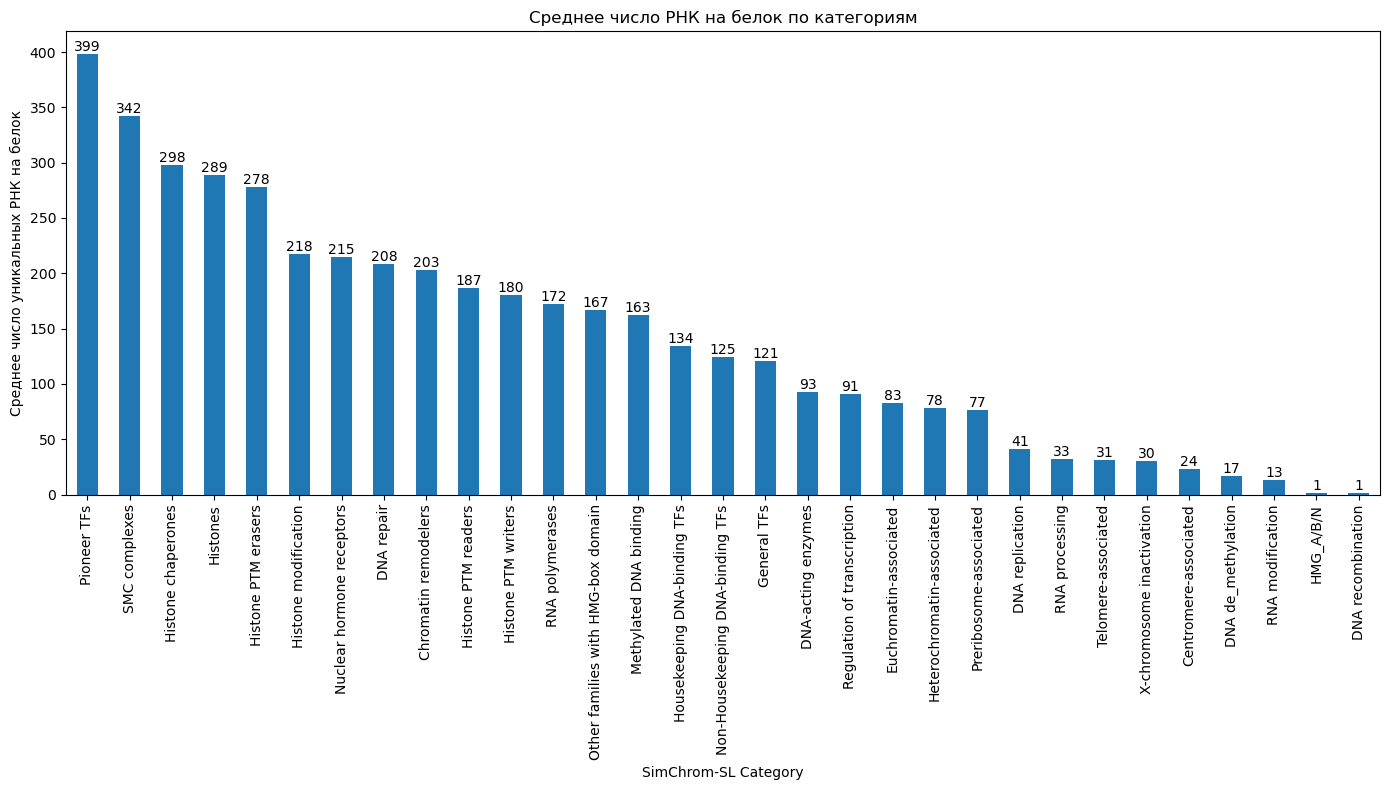

NameError: name 'rna_per_protein_group' is not defined

In [22]:
avg_rnas_per_protein_in_group_simple(covid_lnc1)
rna_per_protein_group(covid_lnc1)

In [28]:
covid_lnc1_ensured = covid_lnc1.dropna(subset=['strong'], inplace=False)

In [31]:
covid_lnc1_ensured['Protein names'].value_counts()

Protein names
rRNA 2'-O-methyltransferase fibrillarin                                                                                    70
Splicing factor, proline- and glutamine-rich (hPOMp100) (PSF)                                                              50
Non-POU domain-containing octamer-binding protein (p54(nrb)) (p54nrb) (NMT55)                                              44
RNA-binding motif protein, X chromosome [Cleaved into: RNA-binding motif protein, X chromosome, N-terminally processed]    35
RNA binding protein fox-1 homolog 2                                                                                        26
                                                                                                                           ..
RNA helicase aquarius                                                                                                       1
Cell cycle and apoptosis regulator protein 2 (DBC-1) (DBC.1) (NET35)                                    

In [37]:
covid_lnc1_ensured.to_csv("~/mandybura_data/minobr24/rna_interactions/covid_rna_interactions_2025/lncrna1_interactions_strong.csv", sep=";")

In [42]:
cat_col = "SimChrom-SL Category"
val_col = "logFC"

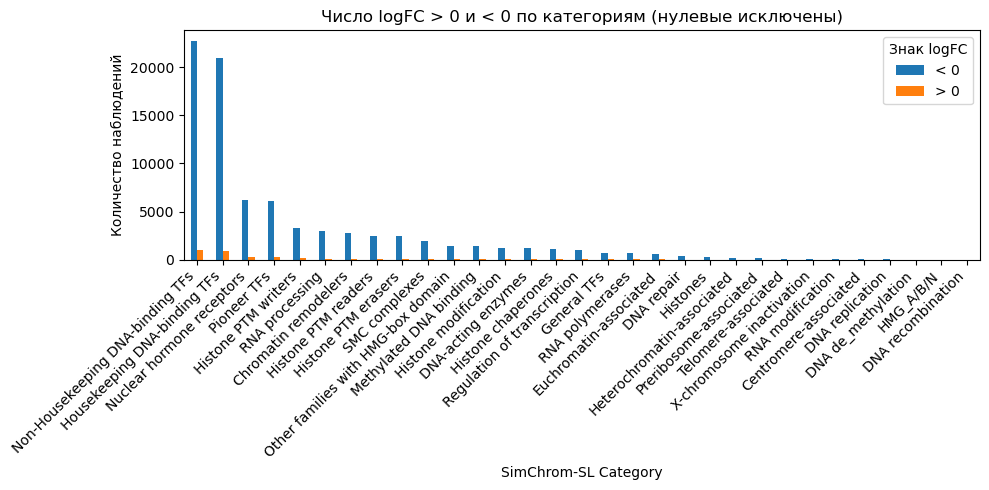

In [44]:
tmp = covid_lnc1[[cat_col, val_col]].copy()
tmp[cat_col] = tmp[cat_col].astype(str).str.strip()
tmp = tmp.dropna(subset=[cat_col, val_col])
tmp = tmp[tmp[val_col] != 0]

# Признак знака logFC
tmp["sign"] = np.where(tmp[val_col] > 0, "> 0", "< 0")

# Подсчёты по категориям и знаку
counts = (
    tmp.groupby([cat_col, "sign"])
       .size()
       .unstack("sign", fill_value=0)
)

# (необязательно) отсортируем категории по суммарному числу наблюдений
counts = counts.assign(_total=counts.sum(axis=1))\
               .sort_values("_total", ascending=False)\
               .drop(columns="_total")

# Группированный barplot
ax = counts.plot(kind="bar", figsize=(10, 5))
ax.set_xlabel(cat_col)
ax.set_ylabel("Количество наблюдений")
ax.set_title("Число logFC > 0 и < 0 по категориям (нулевые исключены)")
ax.legend(title="Знак logFC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [45]:


def plot_symbol_counts_by_sign(
    df=covid_lnc1_ensured,
    cat_col="SimChrom-SL Category",
    val_col="logFC",
    symbol_col="Interactor1.Symbol",
    stacked=False,
    figsize=(10, 5)
):
    # оставить нужные колонки и почистить пропуски
    tmp = df[[cat_col, val_col, symbol_col]].copy()
    tmp[cat_col] = tmp[cat_col].astype(str).str.strip()
    tmp[symbol_col] = tmp[symbol_col].astype(str).str.strip()
    tmp = tmp.dropna(subset=[cat_col, val_col, symbol_col])

    # исключаем нули logFC и размечаем знак
    tmp = tmp[tmp[val_col] != 0].copy()
    tmp["sign"] = np.where(tmp[val_col] > 0, "> 0", "< 0")

    # считаем уникальные символы на пару (категория, знак)
    counts = (
        tmp.groupby([cat_col, "sign"])[symbol_col]
           .nunique()                          # ключевое изменение: считаем уникальные Interactor1.Symbol
           .unstack("sign", fill_value=0)
    )

    # сортировка по суммарному числу символов
    counts = counts.assign(_total=counts.sum(axis=1))\
                   .sort_values("_total", ascending=False)\
                   .drop(columns="_total")

    # график
    ax = counts.plot(kind="bar", stacked=stacked, figsize=figsize)
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f"Уникальных {symbol_col}")
    ax.set_title(f"Число уникальных {symbol_col} с logFC > 0 и < 0 по категориям")
    ax.legend(title="Знак logFC")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return counts


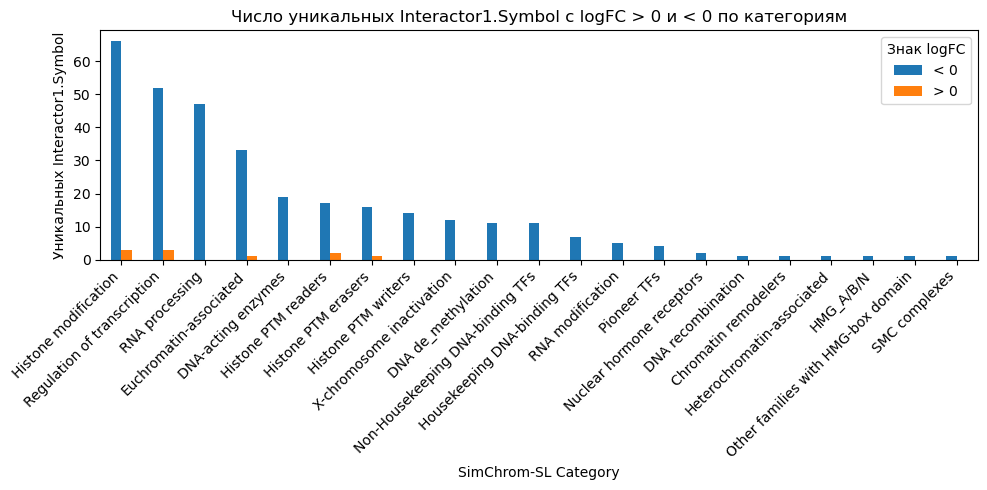

sign,< 0,> 0
SimChrom-SL Category,,
Histone modification,66,3
Regulation of transcription,52,3
RNA processing,47,0
Euchromatin-associated,33,1
DNA-acting enzymes,19,0
Histone PTM readers,17,2
Histone PTM erasers,16,1
Histone PTM writers,14,0
X-chromosome inactivation,12,0


In [46]:
plot_symbol_counts_by_sign()

In [47]:
covid_lnc1_ensured_plus = covid_lnc1_ensured[covid_lnc1_ensured['logFC'] > 0] 

In [48]:
covid_lnc1_ensured_plus

,Unnamed: 0_x,Interactor2.Symbol,Protein,Protein names,UniProt Localization,HPA Localization,OpenCell Localization,SimChrom Category,SimChrom-SL Category,MS-based studies,...,weak,predict,Unnamed: 0_y,ensemblID,logFC,AveExpr,t,P.Value,adj.P.Val,B
5277,2578036,RBMX,P38159,"RNA-binding motif protein, X chromosome [Cleav...",Nucleus (ECO:0000269),Nucleoplasm (Supported),nucleoplasm (annotations_grade_3),"Nuclear RNA binding proteins, RNA processing, ...",Euchromatin-associated,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,60,ENSG00000180769,1.766819,-0.989481,4.411777,0.000084,0.000419,0.857124
7554,1335379,HDAC9,Q9UKV0,Histone deacetylase 9 (HD9),Nucleus (ECO:0000250),Nucleoplasm (Approved),NaN,"Histone modification, Histone PTM erasers",Histone PTM erasers,NaN,...,NaN,NaN,862,ENSG00000231535,3.075093,0.196656,2.531430,0.015708,0.042470,-4.103648
11037,2819208,SMARCA4,P51532,Transcription activator BRG1,"Nucleus (ECO:0000255), Nucleus (ECO:0000269)","Nucleoli fibrillar center (Supported), Nucleol...","chromatin (annotations_grade_2), nucleoplasm (...","DNA-acting enzymes, Chromatin remodelers, Hist...",Histone PTM readers,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,862,ENSG00000231535,3.075093,0.196656,2.531430,0.015708,0.042470,-4.103648
11345,2821975,SMARCA4,P51532,Transcription activator BRG1,"Nucleus (ECO:0000255), Nucleus (ECO:0000269)","Nucleoli fibrillar center (Supported), Nucleol...","chromatin (annotations_grade_2), nucleoplasm (...","DNA-acting enzymes, Chromatin remodelers, Hist...",Histone PTM readers,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,ChIP-seq,NaN,60,ENSG00000180769,1.766819,-0.989481,4.411777,0.000084,0.000419,0.857124
17254,935960,FBL,P22087,rRNA 2'-O-methyltransferase fibrillarin,"Nucleolus (ECO:0000269), Nucleoplasm (ECO:0000...","Nucleoli fibrillar center (Supported), Nucleop...",nucleolus_fc_dfc (annotations_grade_3),"Histone modification, Nuclear RNA binding prot...",Histone modification,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,PAR-CLIP,NaN,60,ENSG00000180769,1.766819,-0.989481,4.411777,0.000084,0.000419,0.857124
17345,929115,FBL,P22087,rRNA 2'-O-methyltransferase fibrillarin,"Nucleolus (ECO:0000269), Nucleoplasm (ECO:0000...","Nucleoli fibrillar center (Supported), Nucleop...",nucleolus_fc_dfc (annotations_grade_3),"Histone modification, Nuclear RNA binding prot...",Histone modification,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,189,ENSG00000213373,1.859831,0.013731,4.593274,0.000049,0.000253,1.395128
17353,928935,FBL,P22087,rRNA 2'-O-methyltransferase fibrillarin,"Nucleolus (ECO:0000269), Nucleoplasm (ECO:0000...","Nucleoli fibrillar center (Supported), Nucleop...",nucleolus_fc_dfc (annotations_grade_3),"Histone modification, Nuclear RNA binding prot...",Histone modification,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,862,ENSG00000231535,3.075093,0.196656,2.531430,0.015708,0.042470,-4.103648
83914,2715496,SFPQ,P23246,"Splicing factor, proline- and glutamine-rich (...","Cytoplasm (ECO:0000269), Nucleus matrix (ECO:0...",Nucleoplasm (Enhanced),"chromatin (annotations_grade_2), nuclear_punct...","DNA-templated transcription, Regulation of tra...",Regulation of transcription,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,60,ENSG00000180769,1.766819,-0.989481,4.411777,0.000084,0.000419,0.857124
84000,2221633,NONO,Q15233,Non-POU domain-containing octamer-binding prot...,"Chromosome (ECO:0000250), Nucleus (ECO:0000269...","Nucleoli (Supported), Nucleoli fibrillar cente...","chromatin (annotations_grade_2), nuclear_punct...","DNA-templated transcription, Regulation of tra...",Regulation of transcription,"Alabert et al., 2014; Alvarez et al., 2023; Gi...",...,NaN,NaN,862,ENSG00000231535,3.075093,0.196656,2.531430,0.015708,0.042470,-4.103648
84020,2714533,SFPQ,P23246,"Splicing factor, proline- and glutamine-rich (...","Cytoplasm (ECO:0000269), Nucleus matrix (ECO:0...",Nucleoplasm (Enha

In [54]:
cols = covid_lnc1_ensured[["SimChrom-SL Category","Protein","Protein names", "logFC", "Interactor1.Symbol"]].sort_values(['logFC'], ascending=False).copy()

In [56]:
cols.tail(10)

,SimChrom-SL Category,Protein,Protein names,logFC,Interactor1.Symbol
11348,Histone PTM readers,P51532,Transcription activator BRG1,-6.573269,XIST
83966,Regulation of transcription,Q00839,Heterogeneous nuclear ribonucleoprotein U (GRI...,-6.573269,XIST
17255,Histone modification,P22087,rRNA 2'-O-methyltransferase fibrillarin,-6.573269,XIST
8896,Histone PTM readers,Q15022,Polycomb protein SUZ12,-6.573269,XIST
9560,Histone PTM readers,P61964,WD repeat-containing protein 5,-6.573269,XIST
7573,Histone PTM erasers,Q9UKV0,Histone deacetylase 9 (HD9),-6.573269,XIST
3011,DNA recombination,Q99728,BRCA1-associated RING domain protein 1 (BARD-1),-6.573269,XIST
83977,Regulation of transcription,Q15233,Non-POU domain-containing octamer-binding prot...,-6.573269,XIST
5276,Euchromatin-associated,P38159,"RNA-binding motif protein, X chromosome [Cleav...",-6.573269,XIST
3010,DNA de_methylation,Q9C0B1,Alpha-ketoglutarate-dependent dioxygenase FTO ...,-6.573269,XIST


In [58]:
JPX = covid_lnc1_ensured[covid_lnc1_ensured["Interactor1.Symbol"] == "JPX"] 

In [60]:
JPX = JPX[["SimChrom-SL Category","Protein","Protein names", "logFC", "Interactor1.Symbol"]]

In [61]:
JPX

,SimChrom-SL Category,Protein,Protein names,logFC,Interactor1.Symbol
3008,DNA de_methylation,Q9C0B1,Alpha-ketoglutarate-dependent dioxygenase FTO ...,-1.816671,JPX
4450,DNA-acting enzymes,Q92900,Regulator of nonsense transcripts 1,-1.816671,JPX
5233,Euchromatin-associated,P38159,"RNA-binding motif protein, X chromosome [Cleav...",-1.816671,JPX
17311,Histone modification,P22087,rRNA 2'-O-methyltransferase fibrillarin,-1.816671,JPX
80408,RNA processing,Q9NR56,Muscleblind-like protein 1,-1.816671,JPX
80551,RNA processing,P09651,Heterogeneous nuclear ribonucleoprotein A1 [Cl...,-1.816671,JPX
81166,RNA processing,Q07955,Serine/arginine-rich splicing factor 1 (ASF-1),-1.816671,JPX
81906,RNA processing,Q96PU8,Protein quaking (Hqk) (HqkI),-1.816671,JPX
82054,RNA processing,P26368,Splicing factor U2AF 65 kDa subunit (hU2AF(65)...,-1.816671,JPX
82426,RNA processing,O43251,RNA binding protein fox-1 homolog 2,-1.816671,JPX


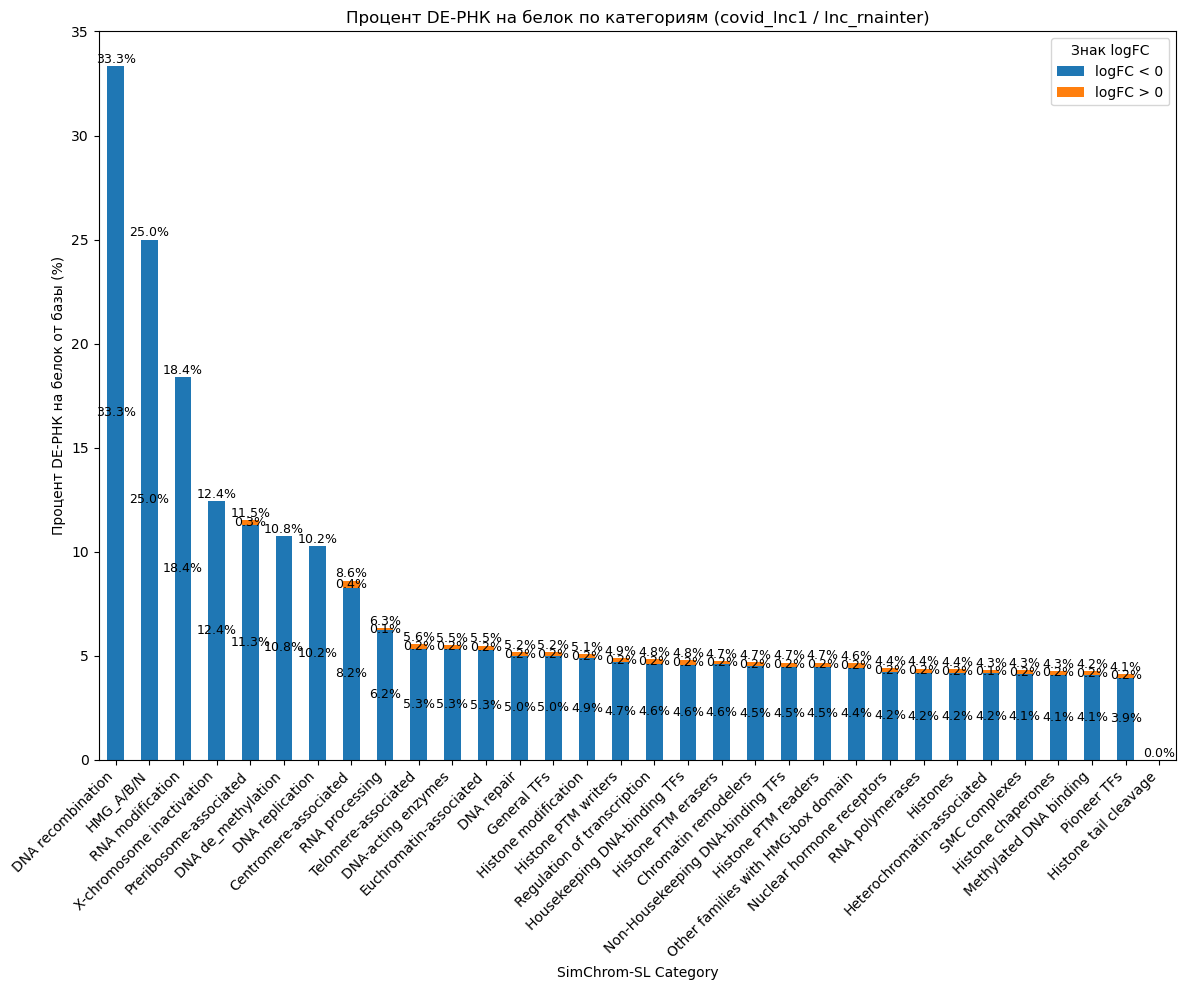

,n_proteins,avg_all,avg_de_pos,avg_de_neg,percent_pos,percent_neg,total_percent
SimChrom-SL Category,,,,,,,
DNA recombination,2,1.500000,0.000000,0.500000,0.000000,33.333333,33.333333
HMG_A/B/N,3,1.333333,0.000000,0.333333,0.000000,25.000000,25.000000
RNA modification,8,45.500000,0.000000,8.375000,0.000000,18.406593,18.406593
X-chromosome inactivation,4,180.750000,0.000000,22.500000,0.000000,12.448133,12.448133
Preribosome-associated,3,665.333333,1.666667,75.000000,0.250501,11.272545,11.523046
DNA de_methylation,3,52.666667,0.000000,5.666667,0.000000,10.759494,10.759494
DNA replication,2,200.000000,0.000000,20.500000,0.000000,10.250000,10.250000
Centromere-associated,5,109.200000,0.400000,9.000000,0.366300,8.241758,8.608059
RNA processing,98,473.806122,0.418367,29.520408,0.088299,6.230483,6.318782


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_de_percent_by_category(
    lnc_rnainter: pd.DataFrame,
    covid_lnc1: pd.DataFrame,
    rna_col: str = "Interactor1.Symbol",
    prot_col: str = "Interactor2.Symbol",
    cat_col: str = "SimChrom-SL Category",
    logfc_col: str = "logFC",
    sort_by: str = "total_percent",   # "total_percent" | "percent_pos" | "percent_neg" | None
    figsize=(12, 10),
    annotate: bool = True,
    decimals: int = 1,
    fillna_percent_with_zero: bool = False
):
    """
    Рисует stacked-bar: процент DE-РНК на белок по категориям (covid_lnc1 / lnc_rnainter),
    с раскладкой процента на logFC>0 и logFC<0.
    """

    # ===== 1) БАЗА: среднее число уникальных РНК на белок по категориям =====
    base = lnc_rnainter[[rna_col, prot_col, cat_col]].dropna().copy()
    for c in (rna_col, prot_col, cat_col):
        base[c] = base[c].astype(str).str.strip()

    # однозначная категория для каждого белка
    prot_cat = (base.drop_duplicates([prot_col, cat_col])
                    .set_index(prot_col)[cat_col])
    prot_cat = prot_cat[~prot_cat.index.duplicated(keep="first")]

    all_proteins = prot_cat.index

    # число уникальных РНК на каждый белок (по полной базе)
    rnas_per_prot_all = (base.groupby(prot_col)[rna_col]
                              .nunique()
                              .reindex(all_proteins, fill_value=0))

    # агрегация по категориям
    n_prot_by_cat = pd.Series(prot_cat).value_counts().sort_index()
    sum_all_by_cat = rnas_per_prot_all.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_all_by_cat = (sum_all_by_cat / n_prot_by_cat).astype(float)
    avg_all_by_cat[n_prot_by_cat == 0] = np.nan

    # ===== 2) COVID: среднее число DE-РНК на белок по знакам logFC =====
    if logfc_col not in covid_lnc1.columns:
        raise ValueError(f"В covid_lnc1 нет колонки '{logfc_col}'.")

    cov = covid_lnc1[[rna_col, prot_col, logfc_col]].dropna(subset=[rna_col, prot_col, logfc_col]).copy()
    for c in (rna_col, prot_col):
        cov[c] = cov[c].astype(str).str.strip()

    pos_per_prot = (cov[cov[logfc_col] > 0]
                    .groupby(prot_col)[rna_col]
                    .nunique()
                    .reindex(all_proteins, fill_value=0))
    neg_per_prot = (cov[cov[logfc_col] < 0]
                    .groupby(prot_col)[rna_col]
                    .nunique()
                    .reindex(all_proteins, fill_value=0))

    sum_pos_by_cat = pos_per_prot.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)
    sum_neg_by_cat = neg_per_prot.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)

    with np.errstate(divide='ignore', invalid='ignore'):
        avg_pos_by_cat = (sum_pos_by_cat / n_prot_by_cat).astype(float)
        avg_neg_by_cat = (sum_neg_by_cat / n_prot_by_cat).astype(float)
    avg_pos_by_cat[n_prot_by_cat == 0] = np.nan
    avg_neg_by_cat[n_prot_by_cat == 0] = np.nan

    # ===== 3) ПРОЦЕНТЫ: (avg_DE / avg_all) * 100 =====
    with np.errstate(divide='ignore', invalid='ignore'):
        percent_pos = (avg_pos_by_cat / avg_all_by_cat) * 100
        percent_neg = (avg_neg_by_cat / avg_all_by_cat) * 100

    if fillna_percent_with_zero:
        percent_pos = percent_pos.fillna(0.0)
        percent_neg = percent_neg.fillna(0.0)

    result = pd.DataFrame({
        "n_proteins": n_prot_by_cat,
        "avg_all": avg_all_by_cat,
        "avg_de_pos": avg_pos_by_cat,
        "avg_de_neg": avg_neg_by_cat,
        "percent_pos": percent_pos,
        "percent_neg": percent_neg
    })
    result["total_percent"] = result["percent_pos"].fillna(0) + result["percent_neg"].fillna(0)

    # ===== 4) сортировка =====
    if sort_by in result.columns:
        result = result.sort_values(sort_by, ascending=False, na_position="last")

    # ===== 5) график (stacked bar: neg снизу, pos сверху) =====
    plot_df = result[["percent_neg", "percent_pos"]].fillna(0)
    ax = plot_df.plot(kind="bar", stacked=True, figsize=figsize)
    ax.set_ylabel("Процент DE-РНК на белок от базы (%)")
    ax.set_xlabel(cat_col)
    ax.set_title("Процент DE-РНК на белок по категориям (covid_lnc1 / lnc_rnainter)")
    ax.legend(["logFC < 0", "logFC > 0"], title="Знак logFC", loc="upper right")

    if annotate and not plot_df.empty:
        ymax = (plot_df.sum(axis=1)).max()
        pad = max(ymax * 0.05, 1.0)
        for i, (neg, pos, tot) in enumerate(zip(result["percent_neg"].fillna(0),
                                                result["percent_pos"].fillna(0),
                                                result["total_percent"].fillna(0))):
            # подписи внутри сегментов
            if neg > 0:
                ax.text(i, neg/2, f"{neg:.{decimals}f}%", ha="center", va="center", fontsize=9)
            if pos > 0:
                ax.text(i, neg + pos/2, f"{pos:.{decimals}f}%", ha="center", va="center", fontsize=9)
            # итог над столбиком
            ax.text(i, neg + pos + 0.01, f"{tot:.{decimals}f}%", ha="center", va="bottom", fontsize=9)
        ax.set_ylim(0, ymax + pad)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return result
plot_de_percent_by_category(lnc_rnainter, covid_lnc1)

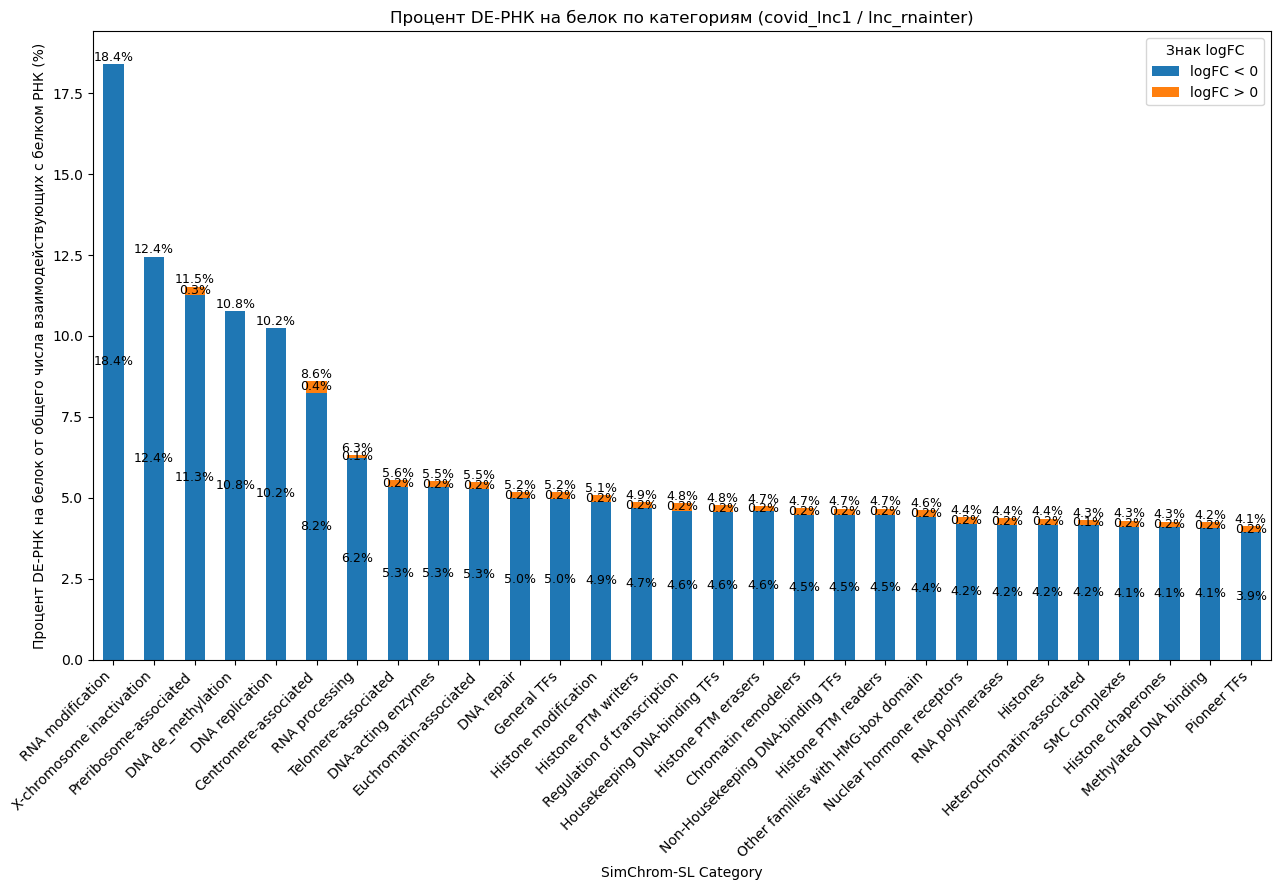

,n_proteins,avg_all,avg_de_pos,avg_de_neg,percent_pos,percent_neg,total_percent
SimChrom-SL Category,,,,,,,
RNA modification,8,45.500000,0.000000,8.375000,0.000000,18.406593,18.406593
X-chromosome inactivation,4,180.750000,0.000000,22.500000,0.000000,12.448133,12.448133
Preribosome-associated,3,665.333333,1.666667,75.000000,0.250501,11.272545,11.523046
DNA de_methylation,3,52.666667,0.000000,5.666667,0.000000,10.759494,10.759494
DNA replication,2,200.000000,0.000000,20.500000,0.000000,10.250000,10.250000
Centromere-associated,5,109.200000,0.400000,9.000000,0.366300,8.241758,8.608059
RNA processing,98,473.806122,0.418367,29.520408,0.088299,6.230483,6.318782
Telomere-associated,6,375.000000,0.833333,20.000000,0.222222,5.333333,5.555556
DNA-acting enzymes,18,1218.166667,2.277778,64.888889,0.186984,5.326766,5.513750


In [27]:

def plot_de_percent_by_category(
    lnc_rnainter: pd.DataFrame,
    covid_lnc1: pd.DataFrame,
    rna_col: str = "Interactor1.Symbol",
    prot_col: str = "Interactor2.Symbol",
    cat_col: str = "SimChrom-SL Category",
    logfc_col: str = "logFC",
    sort_by: str = "total_percent",   # "total_percent" | "percent_pos" | "percent_neg" | None
    figsize=(13, 9),
    annotate: bool = True,
    decimals: int = 1,
    fillna_percent_with_zero: bool = False,
    min_avg_all: float | None = None  # ← фильтр по avg_all
):
    # ===== 1) база: среднее число уникальных РНК на белок =====
    base = lnc_rnainter[[rna_col, prot_col, cat_col]].dropna().copy()
    for c in (rna_col, prot_col, cat_col):
        base[c] = base[c].astype(str).str.strip()

    prot_cat = (base.drop_duplicates([prot_col, cat_col])
                    .set_index(prot_col)[cat_col])
    prot_cat = prot_cat[~prot_cat.index.duplicated(keep="first")]
    all_proteins = prot_cat.index

    rnas_per_prot_all = (base.groupby(prot_col)[rna_col]
                              .nunique()
                              .reindex(all_proteins, fill_value=0))
    n_prot_by_cat = pd.Series(prot_cat).value_counts().sort_index()
    sum_all_by_cat = rnas_per_prot_all.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_all_by_cat = (sum_all_by_cat / n_prot_by_cat).astype(float)
    avg_all_by_cat[n_prot_by_cat == 0] = np.nan

    # ===== 2) covid: среднее число DE-РНК по знакам logFC =====
    if logfc_col not in covid_lnc1.columns:
        raise ValueError(f"В covid_lnc1 нет колонки '{logfc_col}'.")

    cov = covid_lnc1[[rna_col, prot_col, logfc_col]].dropna(subset=[rna_col, prot_col, logfc_col]).copy()
    for c in (rna_col, prot_col):
        cov[c] = cov[c].astype(str).str.strip()

    pos_per_prot = (cov[cov[logfc_col] > 0]
                    .groupby(prot_col)[rna_col]
                    .nunique()
                    .reindex(all_proteins, fill_value=0))
    neg_per_prot = (cov[cov[logfc_col] < 0]
                    .groupby(prot_col)[rna_col]
                    .nunique()
                    .reindex(all_proteins, fill_value=0))

    sum_pos_by_cat = pos_per_prot.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)
    sum_neg_by_cat = neg_per_prot.groupby(prot_cat).sum().reindex(n_prot_by_cat.index, fill_value=0)

    with np.errstate(divide='ignore', invalid='ignore'):
        avg_pos_by_cat = (sum_pos_by_cat / n_prot_by_cat).astype(float)
        avg_neg_by_cat = (sum_neg_by_cat / n_prot_by_cat).astype(float)
    avg_pos_by_cat[n_prot_by_cat == 0] = np.nan
    avg_neg_by_cat[n_prot_by_cat == 0] = np.nan

    # ===== 3) проценты =====
    with np.errstate(divide='ignore', invalid='ignore'):
        percent_pos = (avg_pos_by_cat / avg_all_by_cat) * 100
        percent_neg = (avg_neg_by_cat / avg_all_by_cat) * 100

    if fillna_percent_with_zero:
        percent_pos = percent_pos.fillna(0.0)
        percent_neg = percent_neg.fillna(0.0)

    result = pd.DataFrame({
        "n_proteins": n_prot_by_cat,
        "avg_all": avg_all_by_cat,
        "avg_de_pos": avg_pos_by_cat,
        "avg_de_neg": avg_neg_by_cat,
        "percent_pos": percent_pos,
        "percent_neg": percent_neg
    })
    result["total_percent"] = result["percent_pos"].fillna(0) + result["percent_neg"].fillna(0)

    # ===== 4) фильтр по avg_all > min_avg_all =====
    if min_avg_all is not None:
        result = result[result["avg_all"] > min_avg_all]

    # ===== 5) сортировка =====
    if sort_by in result.columns:
        result = result.sort_values(sort_by, ascending=False, na_position="last")

    # если после фильтра ничего не осталось — выходим
    if result.empty:
        print("Нет категорий, удовлетворяющих условию фильтра.")
        return result

    # ===== 6) график =====
    plot_df = result[["percent_neg", "percent_pos"]].fillna(0)
    ax = plot_df.plot(kind="bar", stacked=True, figsize=figsize)
    ax.set_ylabel("Процент DE-РНК на белок от общего числа взаимодействующих с белком РНК (%)")
    ax.set_xlabel(cat_col)
    ax.set_title("Процент DE-РНК на белок по категориям (covid_lnc1 / lnc_rnainter)")
    ax.legend(["logFC < 0", "logFC > 0"], title="Знак logFC", loc="upper right")

    if annotate and not plot_df.empty:
        ymax = (plot_df.sum(axis=1)).max()
        pad = max(ymax * 0.05, 1.0)
        for i, (neg, pos, tot) in enumerate(zip(result["percent_neg"].fillna(0),
                                                result["percent_pos"].fillna(0),
                                                result["total_percent"].fillna(0))):
            if neg > 0:
                ax.text(i, neg/2, f"{neg:.{decimals}f}%", ha="center", va="center", fontsize=9)
            if pos > 0:
                ax.text(i, neg + pos/2, f"{pos:.{decimals}f}%", ha="center", va="center", fontsize=9)
            ax.text(i, neg + pos + 0.01, f"{tot:.{decimals}f}%", ha="center", va="bottom", fontsize=9)
        ax.set_ylim(0, ymax + pad)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return result
plot_de_percent_by_category(lnc_rnainter, covid_lnc1, min_avg_all=5)